## Genomics

Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (*Science*, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.

1. Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable. 

2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes. 

3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values. 

5. Make a plot that shows the cross validated MSE as $alpha$ varies. For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?

6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

7. Why do regularization methods lend themselves to scenarios like precision health? 

8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

plt.rcParams["figure.figsize"] = (8,5)

In [4]:
golub = pd.read_csv("golub.csv")

# 0 = ALLB or ALLT, 1 = AML
golub["target"] = golub["cancer"].map({"allB":0, "allT":0, "aml":1})

X = golub.iloc[:,6:-1]
y = golub["target"]

print(golub["cancer"].value_counts())
print(X.shape)

cancer
allB    38
aml     25
allT     9
Name: count, dtype: int64
(72, 7129)


C:\Users\MAydi\AppData\Local\Temp\ipykernel_25376\4144247172.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  golub["target"] = golub["cancer"].map({"allB":0, "allT":0, "aml":1})


Training MSE: 1.469356152237835e-30


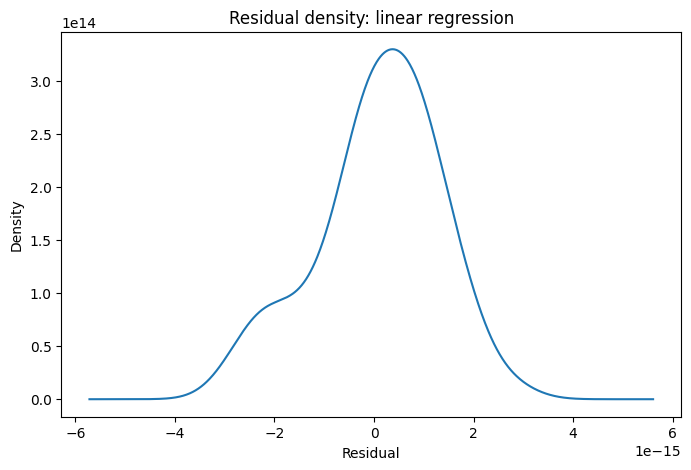

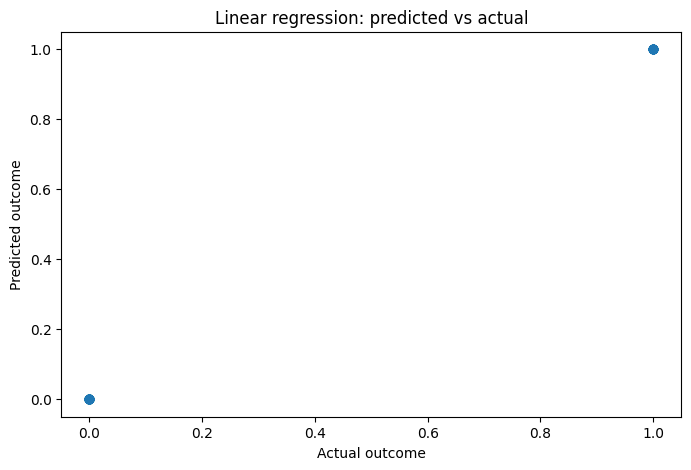

In [5]:
# Linear regression on all genes
lin = LinearRegression()
lin.fit(X, y)
pred_lin = lin.predict(X)
resid_lin = y - pred_lin
mse_train = mean_squared_error(y, pred_lin)
print("Training MSE:", mse_train)

pd.Series(resid_lin).plot(kind="kde", title="Residual density: linear regression")
plt.xlabel("Residual")
plt.show()

plt.scatter(y, pred_lin, alpha=0.7)
plt.xlabel("Actual outcome")
plt.ylabel("Predicted outcome")
plt.title("Linear regression: predicted vs actual")
plt.show()

In [ ]:

X1 = np.column_stack([np.ones(len(y)), X.to_numpy()])
K = X1 @ X1.T

rng = np.random.default_rng(42)
idx = np.arange(len(y))
rng.shuffle(idx)
folds = np.array_split(idx, 5)

cv_mses = []
for fold in folds:
    train = np.setdiff1d(idx, fold)
    Ktr = K[np.ix_(train, train)]
    Kte = K[np.ix_(fold, train)]
    alpha = np.linalg.solve(Ktr + 1e-8*np.eye(len(train)), y.iloc[train].to_numpy())
    pred = Kte @ alpha
    cv_mses.append(np.mean((y.iloc[fold].to_numpy() - pred)**2))

print("Fold MSEs:", cv_mses)
print("Average CV MSE:", np.mean(cv_mses))
print("Std. dev. of CV MSE:", np.std(cv_mses))

Fold MSEs: [np.float64(0.0632929817948415), np.float64(0.042841014282009336), np.float64(0.052217534487482294), np.float64(0.08446655740409888), np.float64(0.03605915811720928)]
Average CV MSE: 0.05577544921712826
Std. dev. of CV MSE: 0.017019891210606684


c:\Users\MAydi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(


Optimal alpha: 0.0036589406739855634
Selected genes: 68
Discarded genes: 7061
['AF000560_at', 'AF002020_at', 'AF006087_at', 'D26579_at', 'D50840_at', 'D86982_at', 'HG2161-HT2231_at', 'J04164_at', 'L13278_at', 'L20941_at', 'M17754_at', 'M19507_at', 'M19645_at', 'M20902_at', 'M22960_at', 'M23197_at', 'M27819_at', 'M27891_at', 'M28713_at', 'M31994_at', 'M34344_at', 'M63138_at', 'M84526_at', 'M95178_at', 'M96326_rna1_at', 'M98539_at', 'U14588_at', 'U34877_at', 'U36621_cds2_at', 'U41816_at', 'U46751_at', 'U50136_rna1_at', 'U51127_at', 'U60062_at', 'U77604_at', 'U82759_at', 'U89942_at', 'X04143_at', 'X14789_at', 'X16706_at', 'X53331_at', 'X56741_at', 'X63753_at', 'X66533_at', 'X69111_at', 'X81479_at', 'X83378_at', 'X87838_at', 'X95735_at', 'X96698_at', 'Y07604_at', 'Y07755_at', 'Y10207_at', 'M96843_at', 'X58072_at', 'L15326_s_at', 'U37055_rna1_s_at', 'X07438_s_at', 'M13690_s_at', 'M26708_s_at', 'M84371_rna1_s_at', 'X12876_s_at', 'M75715_s_at', 'U26312_s_at', 'X85116_rna1_s_at', 'L08010_at', 

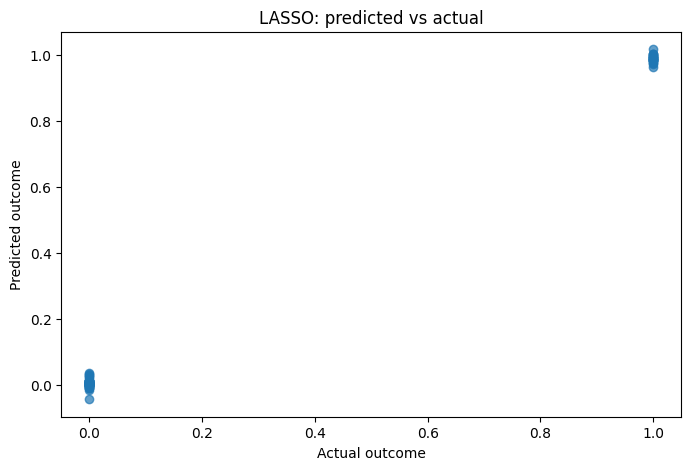

In [7]:
# Cross validated lasso
lasso_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(cv=5, random_state=42, max_iter=10000, n_alphas=50))
])

lasso_pipe.fit(X, y)
lasso = lasso_pipe.named_steps["lasso"]
pred_lasso = lasso_pipe.predict(X)

selected_genes = X.columns[lasso.coef_ != 0].tolist()
discarded = X.shape[1] - len(selected_genes)

print("Optimal alpha:", lasso.alpha_)
print("Selected genes:", len(selected_genes))
print("Discarded genes:", discarded)
print(selected_genes)

plt.scatter(y, pred_lasso, alpha=0.7)
plt.xlabel("Actual outcome")
plt.ylabel("Predicted outcome")
plt.title("LASSO: predicted vs actual")
plt.show()

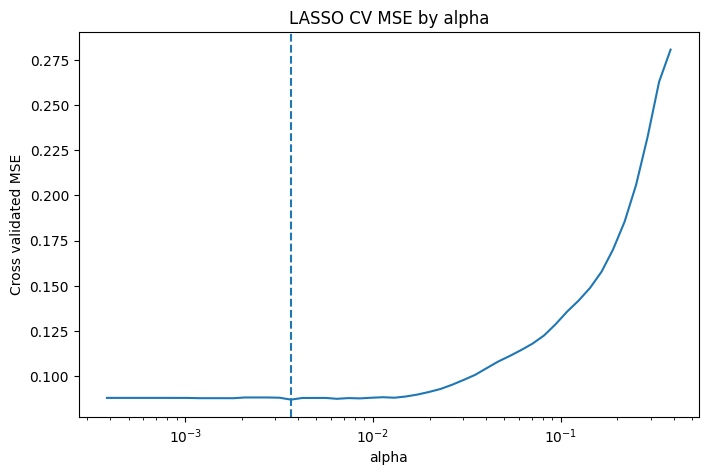

In [8]:
# CV MSE path as alpha varies
mean_mse = lasso.mse_path_.mean(axis=1)

plt.plot(lasso.alphas_, mean_mse)
plt.axvline(lasso.alpha_, linestyle="--")
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Cross validated MSE")
plt.title("LASSO CV MSE by alpha")
plt.show()



1. I coded ALLB and ALLT as 0 and AML as 1, which matches the binary prediction goal.

2. The linear regression fit on all genes has an almost zero training MSE, essentially perfect on the training set.

3. The 5 fold cross validated MSE is much larger than the training MSE. In my run, the average CV MSE was about 0.0558. That gap is a classic high variance result. The model has so many predictors relative to the number of patients that it can interpolate the training data, but it does not generalize as cleanly to new folds.

4. The cross validated lasso keeps 68 genes and discards 7061. The selected genes are printed in the code output. This is a much sparser model, and that makes it easier to interpret and usually more stable out of sample.

5. In the alpha plot, very large alpha values push too many coefficients toward zero, so the model underfits. Very small alpha values allow too much flexibility, so the model moves toward overfitting. The best penalty is the alpha chosen by `LassoCV`, which here is about 0.00366.

6. Plain linear regression performs perfectly on the training data because there are far more gene predictors than patients, so the model can fit the sample almost exactly. The lasso adds a penalty that shrinks many coefficients to zero, which raises training error a little but improves generalization.

7. Regularization methods are useful in precision health because those settings often have thousands of biological measurements but relatively few patients. Penalized models can reduce noise, improve prediction, and highlight a smaller set of candidate biomarkers.

8. The risk is that a predictive gene signature may not be causal, stable across populations, or robust to measurement changes. If a model is used too aggressively in care decisions, patients could get the wrong treatment based on a pattern that does not hold up outside the training data.